# Clasificadores Bayesianos

El objetivo es construir paso a paso un clasificador bayesiano para reconocer dígitos manuscritos y, a partir de esa construcción, introducir el clasificador **Naive Bayes Gaussiano**.

La práctica sigue dos ideas centrales:

- primero se trabaja con **una única característica** para poder visualizar todas las probabilidades involucradas
- luego se incorporan **dos características** para introducir el supuesto de independencia condicional de Naive Bayes.

In [ ]:
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

from IPython.display import Image, display
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

figure_dir = './AM_NaiveBayes/2_imagenes/'


# 1. Clasificador de Bayes

El clasificador de Bayes aborda la clasificación desde un **modelo probabilístico**.

Para una muestra $x$, estima la probabilidad de pertenencia a cada clase y toma la decisión utilizando esas probabilidades.

# 2. Conceptos de probabilidad fundamentales para clasificación

Antes de construir el clasificador, revisaremos las cantidades que aparecen en la regla de Bayes.

### Probabilidad a priori $P(w_i)$

Representa la probabilidad de observar la clase $w_i$ **antes de conocer el valor de la muestra**.

En un conjunto de entrenamiento puede estimarse como la proporción de ejemplos de esa clase.

***Ej. Cuál es la probabilidad de encontrar individuos anémicos en una población de individuos anémicos + sanos***

### Probabilidad condicional $p(x\mid w_i)$ — *likelihood*

Indica qué tan compatible es observar el valor $x$ si sabemos que la muestra pertenece a la clase $w_i$.

Para variables continuas, como la característica que usaremos en esta práctica, trabajaremos con una **función de densidad de probabilidad**.

***Ej. Tengo 2 grupos etiquetados con sanos y anémicos, cuál es la probabilidad de sacar un conteo de glóbulos rojos 2.000.000, conociendo la clase a la que pertenece la muestra.***

### Densidad conjunta $p(x,w_i)$

Probabilidad de observar la muestra $x$ con la etiqueta $w_i$

Combina la evidencia proporcionada por $x$ con la probabilidad a priori de la clase:

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

***Ej. Ahora tengo todas las muestras de los 2 grupos mezcladas, cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 y que sea un individuo sano***

### Densidad marginal $p(x)$

Representa la densidad de observar $x$ sin conocer la clase. Para dos clases:

$$p(x)=p(x,w_0)+p(x,w_1).$$

Para varias clases:

$$
p(x) = \sum\limits_{j=1}^{c}p(x,w_j) = \sum\limits_{j=1}^{c}p(x|w_j)P(w_j)
$$

***Ej. cuál es la probabilidad de sacar un conteo de glóbulos rojos de 2.000.000 sin importar la clase***

### Probabilidad a posteriori $P(w_i\mid x)$

Probabilidad de observar una etiqueta $w_i$  conociendo el valor de la muestra $x$

Se obtiene mediante la regla de Bayes:

$$P(w_i\mid x)=\frac{p(x\mid w_i)P(w_i)}{p(x)}=\frac{p(x,w_i)}{p(x)}.$$

## Clasificador Bayesiano

El clasificador asigna $x$ a la clase con mayor probabilidad a posteriori:

$$\hat w=\arg\max_{w_i}P(w_i\mid x).$$

Como $p(x)$ es el mismo para todas las clases al comparar una misma muestra, la decisión también puede escribirse como

$$\hat w_{MAP}=\arg\max_{w_i} p(x\mid w_i)P(w_i).$$

Esta regla se denomina **máxima a posteriori (MAP)**.

# 3. Ejemplo de aplicación: OCR de dígitos manuscritos 0 y 1

Implementar un clasificador de Bayes para el reconocimiento óptico de caracteres (OCR) de los dígitos manuscritos **0 y 1**.

A continuación se muestran ejemplos de las imágenes binarizadas que utilizaremos.

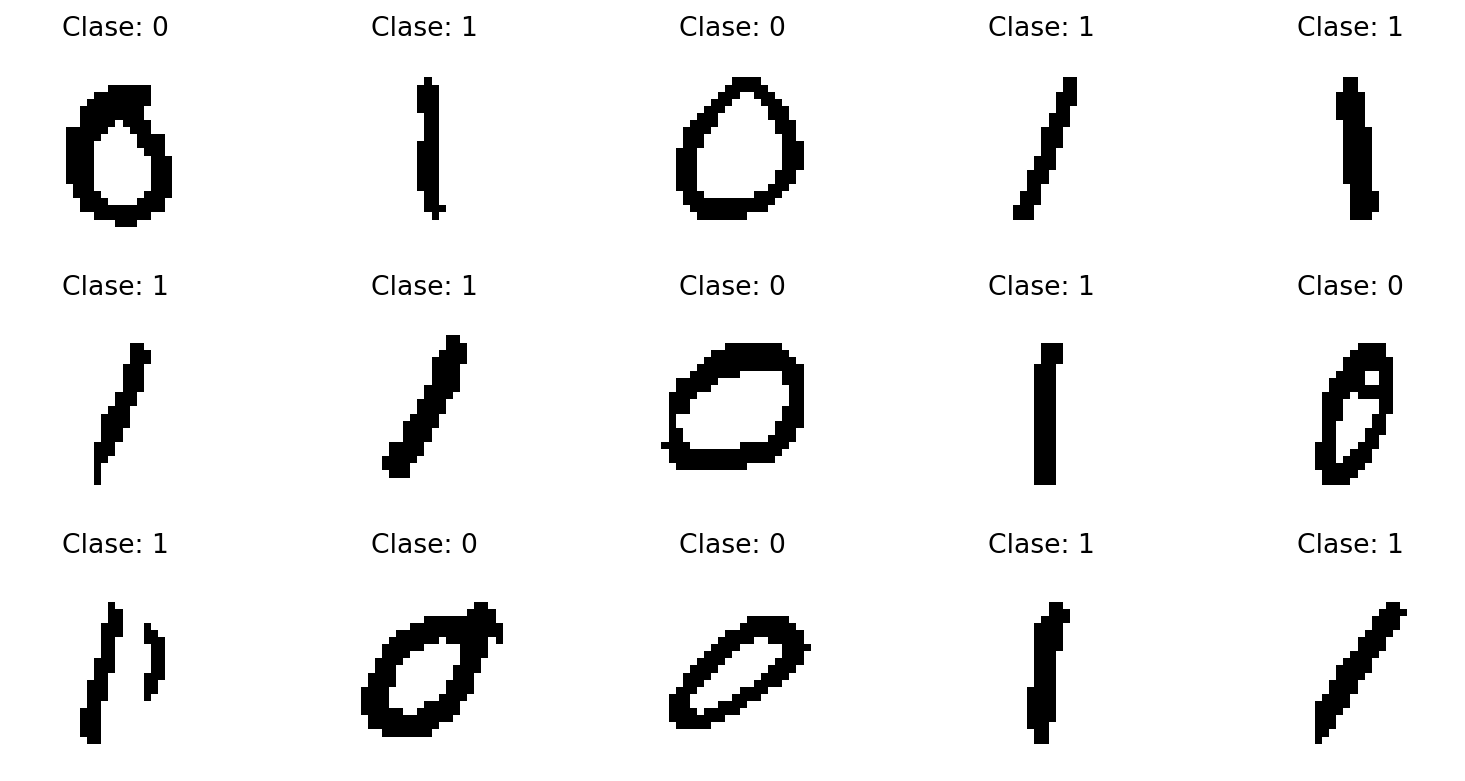

In [ ]:
display(Image(filename=str(figure_dir + 'digitos_0_1.png'), width=800))

Cada imagen está almacenada originalmente como un vector de 784 intensidades, correspondiente a una imagen de $28\times 28$ píxeles. Después de aplicar un umbral de 127, cada píxel queda representado por 0 o 1.

Para comenzar con un problema unidimensional, resumiremos cada imagen mediante una única característica que en esta práctica denominaremos **brillo global**:

$$x=\#\{\text{píxeles con valor }0\}.$$

Es decir, se cuenta la cantidad de píxeles de fondo según la convención de binarización utilizada.

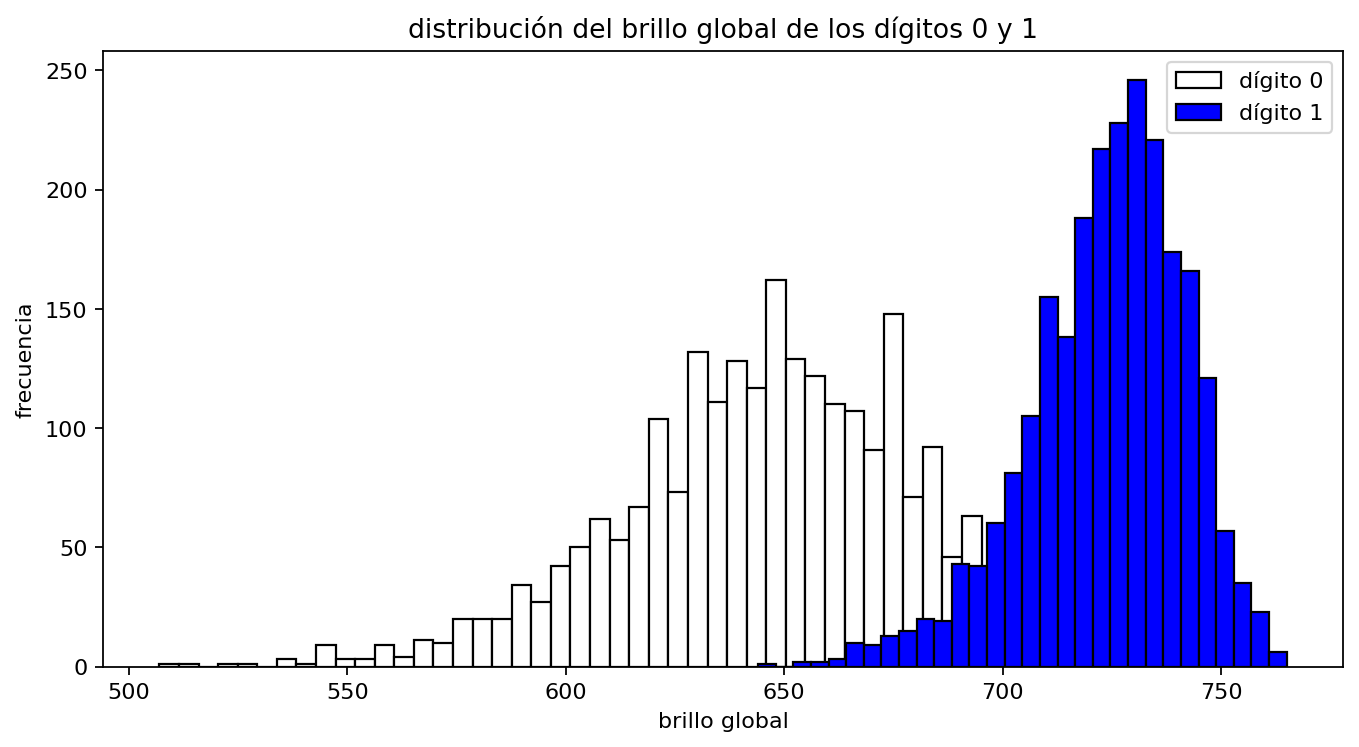

In [ ]:
display(Image(filename=str(figure_dir + 'brillo_global_hist.png'), width=800))

Los histogramas muestran que la característica presenta distribuciones diferentes en ambas clases. Como el dataset contiene la misma cantidad de ceros y unos, esperamos probabilidades a priori similares para las dos clases.

Para modelar $p(x\mid w_i)$ aproximaremos la distribución del brillo global de cada clase mediante una distribución normal o gaussiana.

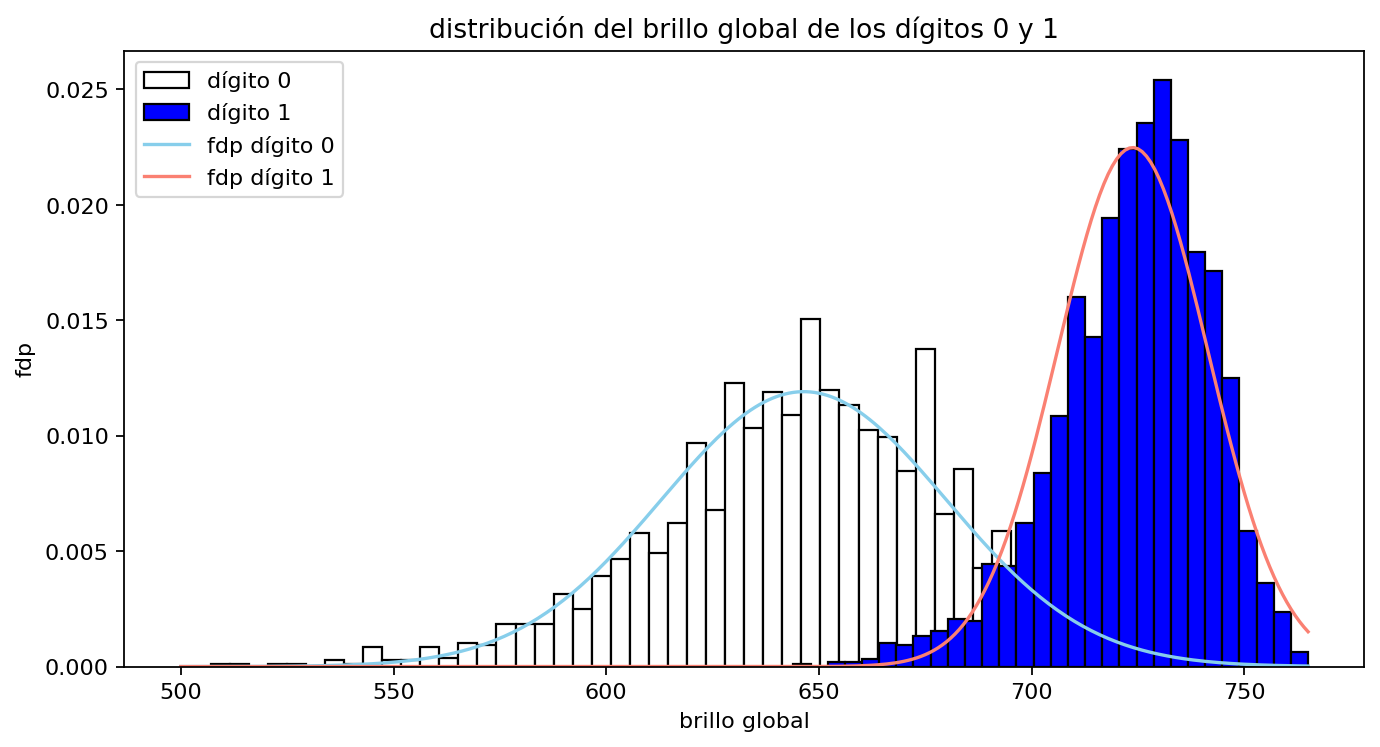

In [ ]:
display(Image(filename=str(figure_dir + 'fdp.png'), width=900))

A partir de $p(x\mid w_i)$ y $P(w_i)$ se obtienen las densidades conjuntas $p(x,w_i)$:

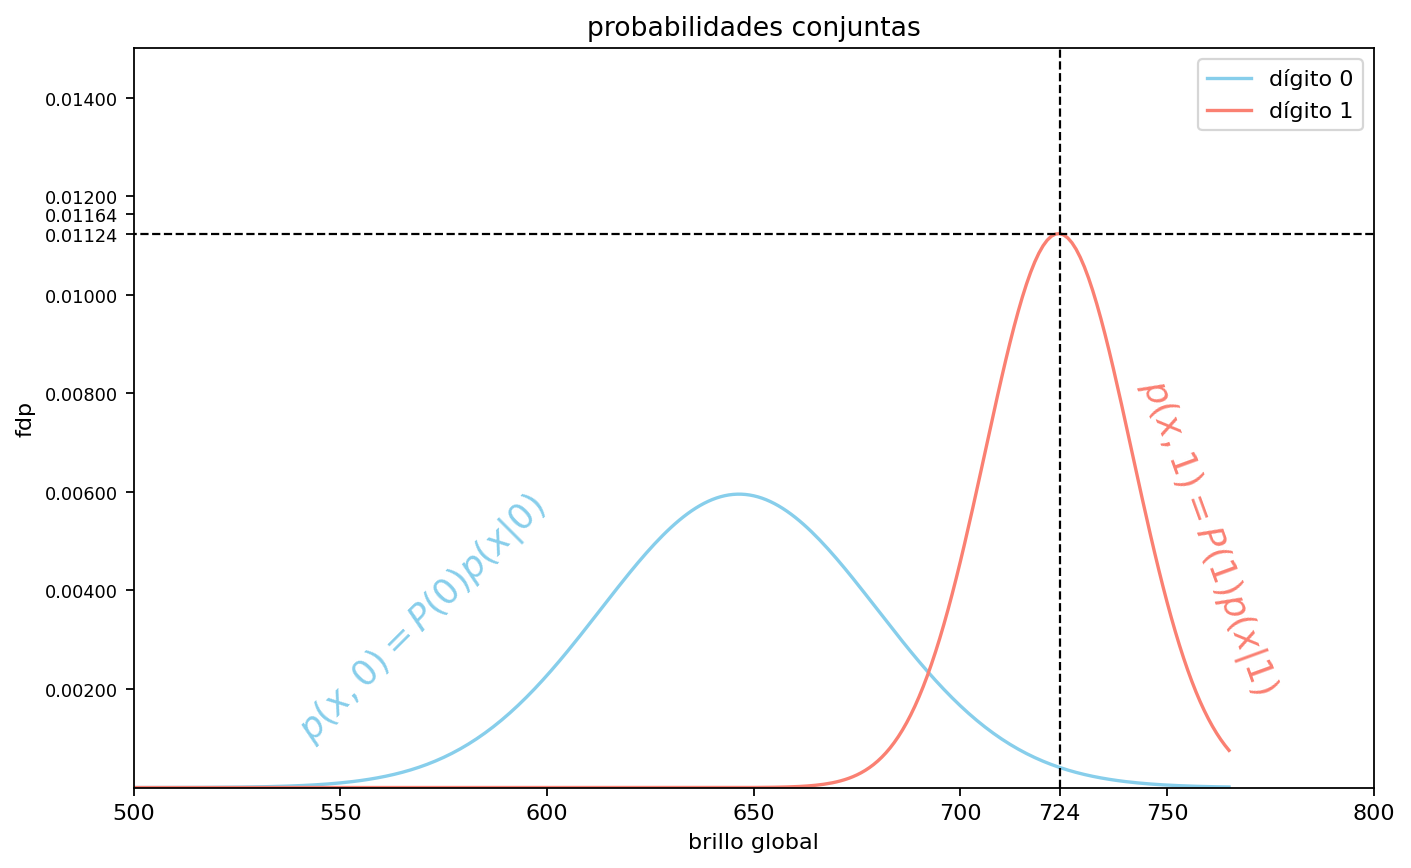

In [ ]:
display(Image(filename=str(figure_dir + 'prob_conjunta.png'), width=1000))

Sumando las densidades conjuntas de las clases se obtiene la densidad marginal $p(x)$:

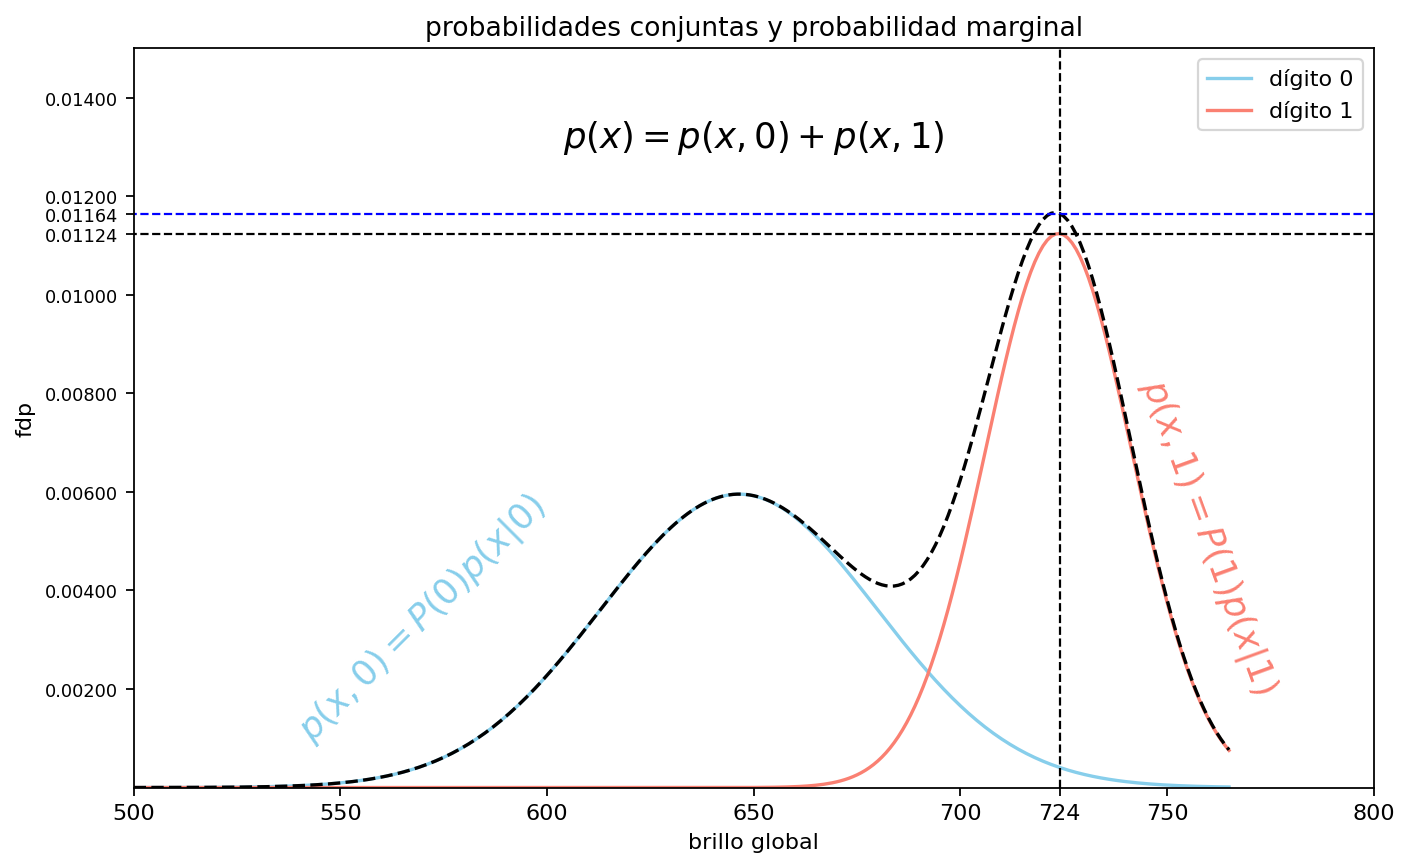

In [ ]:
display(Image(filename=str(figure_dir + 'prob_conjunta_marginal.png'), width=1000))

Finalmente, utilizando la regla de Bayes se obtienen las probabilidades a posteriori:

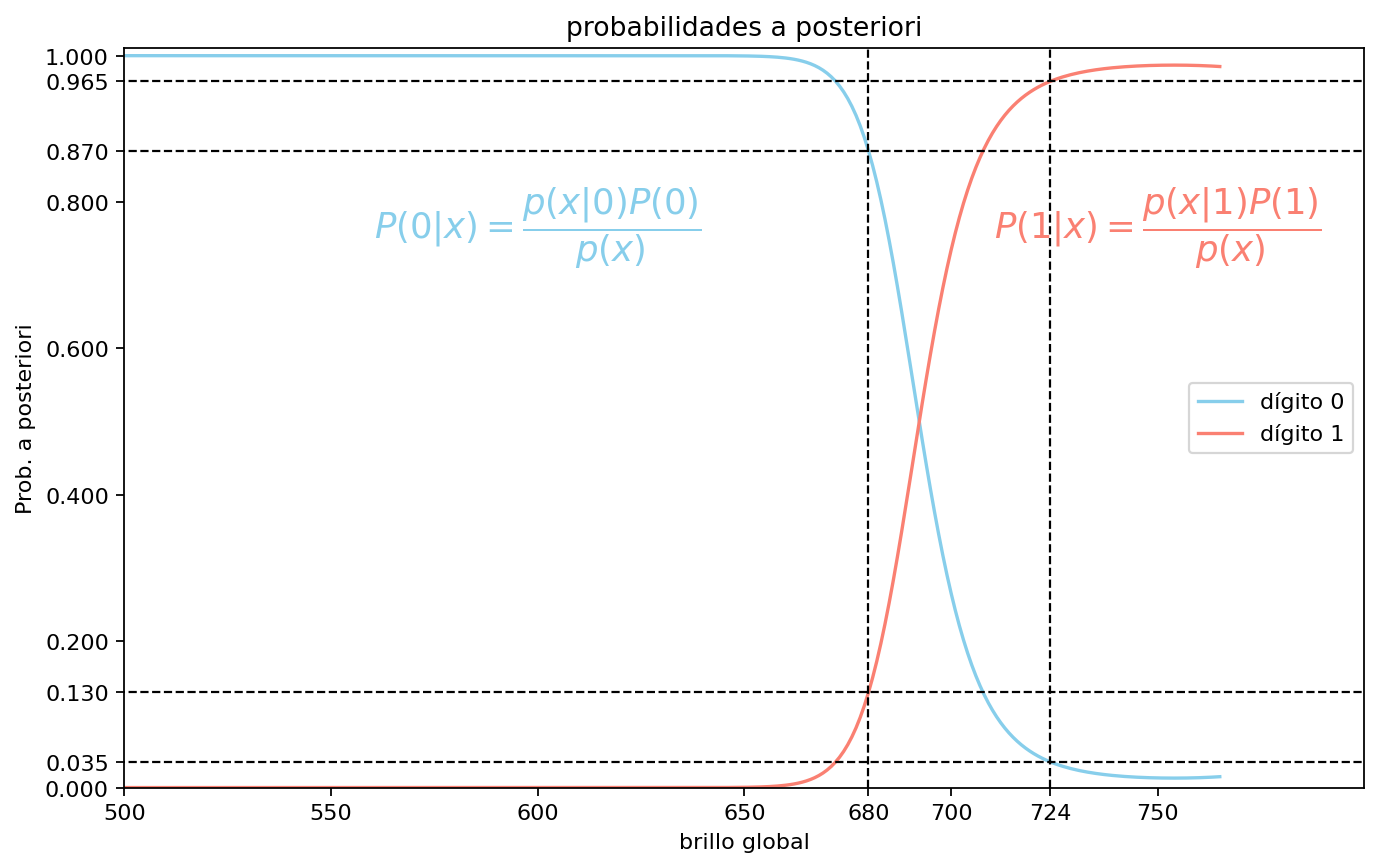

In [ ]:
display(Image(filename=str(figure_dir + 'posteriori.png'), width=900))

## Implementación de la actividad práctica

Reproduzca el análisis anterior a partir del archivo `digitos_0_1.csv`. En cada etapa compare sus resultados con las figuras de referencia.

### 1. Carga y división de los datos

Cargue los datos y sepárelos en entrenamiento y prueba, utilizando un **20% para prueba**, `random_state=0` y `stratify` para preservar la proporción de clases. Separe predictores y etiquetas.

In [6]:
datos = pd.read_csv("./digitos_0_1.csv", sep=",")
datos.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [7]:
target = datos[['target']]
target

,target
0,1
1,1
2,0
3,1
4,1
...,...
5995,1
5996,0
5997,1
5998,0


In [8]:
set_train, set_test = train_test_split(datos, test_size=0.2, random_state=0)

### 2. Procesamiento de datos

Binarice las intensidades utilizando el umbral 127:

- intensidad $>127 \rightarrow 1$;
- intensidad $\le 127 \rightarrow 0$.

Convierta luego los datos a arreglos de NumPy.

In [9]:
X_train = (set_train.drop(columns="target").to_numpy() > 127).astype(np.uint8)
X_test = (set_test.drop(columns="target").to_numpy() > 127).astype(np.uint8)

y_train = set_train["target"].to_numpy()
y_test = set_test["target"].to_numpy()

### 3. Visualización de datos

Visualice los primeros 15 dígitos binarizados del conjunto de entrenamiento en una grilla de $3\times5$ y muestre la clase correspondiente a cada imagen. Compare con la Figura 1.

### 4. Cálculo del brillo global

Implemente una función que reciba una imagen binarizada y devuelva la cantidad de píxeles iguales a 0.

Aplique esta función a cada dígito del conjunto de datos para transformarlo a un conjunto de una única característica.

Aplique la función a entrenamiento y prueba.

Puede utilizar la función [np.apply_along_axis](https://numpy.org/doc/stable/reference/generated/numpy.apply_along_axis.html)

Grafique luego un histograma por clase y compárelo con la Figura 2.

### 5. Probabilidades a priori y parámetros por clase

Calcule $P(w_0)$ y $P(w_1)$ a partir del conjunto de entrenamiento.

Calcule además la media y el desvío estándar del brillo global dentro de cada clase.

### 6. Modelado de las probabilidades condicionales con distribuciones gaussianas

Para cada clase $w_i$, modele el brillo global como

$$x\mid w_i\sim\mathcal N(\mu_i,\sigma_i^2).$$

Implemente una función para evaluar $p(x\mid w_i)$ utilizando [scipy.stats.norm.pdf](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.norm.html). Recuerde que, para una variable continua, la función devuelve una **densidad** y no una probabilidad puntual.

Luego superponga ambas densidades gaussianas sobre los histogramas normalizados (`density=True`) y replique la Figura 3.

### 7. Cálculo de la densidad conjunta

Implemente

$$p(x,w_i)=p(x\mid w_i)P(w_i).$$

Grafique ambas densidades conjuntas y replique la Figura 4.

Verifique el valor para $x=724$ y la clase 1 y márquelo en el gráfico.

### 8. Cálculo de la densidad marginal

Implemente la suma sobre clases:

$$p(x)=\sum_i p(x\mid w_i)P(w_i).$$

Verifique el valor para $x=724$ y grafique la marginal junto con las densidades conjuntas, replicando la Figura 5.

### 9. Cálculo de las probabilidades a posteriori

Implemente la regla de Bayes para calcular $P(w_i\mid x)$ para todas las clases.

Verifique los resultados para $x=680$ y $x=724$ y replique la Figura 6.

### 10. Regla MAP y clasificación

Para clasificar no es necesario calcular explícitamente $p(x)$, porque el denominador es el mismo para todas las clases. Compruebe que

$$\arg\max_i P(w_i\mid x)=\arg\max_i p(x\mid w_i)P(w_i).$$

Obtenga las predicciones sobre el conjunto de prueba y calcule la exactitud (*accuracy*).

# 4. Comparación con Scikit-Learn

Entrene [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html#sklearn.naive_bayes.GaussianNB) utilizando solamente el brillo global. Compare las predicciones y el desempeño con la implementación manual.

Luego inspeccione `class_prior_`, `theta_` y `var_` del objeto entrenado e interprete qué cantidad del desarrollo anterior representa cada atributo.

# 5. Del clasificador de Bayes al clasificador Naive Bayes

Hasta ahora se utilizó una única característica:

$$x=\text{brillo global}.$$

Por eso no fue necesario realizar ningún supuesto sobre relaciones entre características. Al representar una muestra mediante varias características,

$$\mathbf{x}=(x_1,x_2,\ldots,x_d),$$

sería necesario estimar la densidad conjunta

$$p(x_1,x_2,\ldots,x_d\mid w_i).$$

Naive Bayes simplifica este problema suponiendo **independencia condicional dada la clase**:

$$p(x_1,x_2,\ldots,x_d\mid w_i)=\prod_{j=1}^{d}p(x_j\mid w_i).$$

Trabajaremos ahora con dos características extraídas de cada imagen:

1. brillo global;
2. cantidad de transiciones entre píxeles vecinos horizontales y verticales, utilizada como una medida sencilla de bordes/complejidad de la forma.

### 1. Cargar y dividir los datos

Vuelva a cargar el CSV, separe predictores y etiquetas y realice una partición 80/20 con `random_state=0` y `stratify=y`.

### 2. Binarizar y calcular las dos características

Binarice las imágenes usando el mismo umbral.

Implemente las funciones necesarias para obtener el brillo global y la cantidad de transiciones entre píxeles vecinos.

Construya matrices de características de dos columnas para entrenamiento y prueba.

### 3. Entrenamiento y evaluación

Entrene `GaussianNB` con las dos características. Obtenga las predicciones, la exactitud, la matriz de confusión y el `classification_report`. Investigue que devuelve `classification_report`

### 4. Visualización de la clasificación

Realice un diagrama de dispersión sobre el conjunto de prueba:

- eje X: brillo global;
- eje Y: cantidad de transiciones/bordes;
- color: clase predicha.

### 5. Fronteras de decisión

Grafique las regiones de decisión del clasificador sobre el plano de las dos características. Utilice la función provista a continuación y superponga los datos de prueba coloreados según su **clase real**.

In [ ]:
def plot_decision_regions(model, X, y, x_label='Feature 1', y_label='Feature 2', title='Decision regions'):
    """Plot 2D decision regions and true class labels."""
    x_min, x_max = X[:, 0].min() - 5, X[:, 0].max() + 5
    y_min, y_max = X[:, 1].min() - 5, X[:, 1].max() + 5

    x_values = np.linspace(x_min, x_max, 300)
    y_values = np.linspace(y_min, y_max, 300)
    xx, yy = np.meshgrid(x_values, y_values)

    grid = np.column_stack((xx.ravel(), yy.ravel()))
    zz = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, zz, alpha=0.35, cmap=plt.cm.coolwarm)
    scatter = plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='black', cmap=plt.cm.coolwarm)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.colorbar(scatter, label='Clase real')
    plt.show()

### 6. ¿Qué tan razonable es el supuesto *Naive*?

Analice la relación entre las dos características **dentro de cada clase**. Como diagnóstico sencillo, calcule el coeficiente de correlación lineal por clase.

> Importante: correlación nula **no demuestra independencia**. Sin embargo, una correlación claramente distinta de cero sí evidencia dependencia lineal.

En este ejemplo, ¿las dos características parecen cumplir exactamente la independencia condicional?